# Simple ML Models

Baseline classification pipelines using cleaned feature matrix `../data/X_features.parquet` and target labels `../data/y_targets.parquet`. This notebook trains and cross-validates multi-output Logistic Regression, Random Forest, Gradient Boosting, and soft-voting ensemble pipelines — then tunes them with Bayesian hyperparameter search — and reports cross-validated and held-out test performance.

Each of five individual clinical endpoints (BARC 2/3/5 bleeding, CV death, MI, stroke, and bleeding) is modelled as a separate binary target.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models', 'bi_class'))

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

Load the cleaned feature matrix `X` from `../data/X_features.parquet` and the 9 binary clinical outcome targets `y_df` from `../data/y_targets.parquet`, produced by the data cleaning pipeline.

In [ ]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

# One-hot encode the only remaining categorical column so it is not silently
# discarded by the numeric-only `select_dtypes` filter further down (the other
# categoricals were already one-hot encoded in the data-cleaning pipeline).
if 'regimen' in X.columns:
    X = pd.get_dummies(X, columns=['regimen'], dtype=int)

target_features = y_df

## Select Modeling Targets

From the nine available endpoints, keep the five individual clinical outcomes used as modeling targets below — BARC 2/3/5 bleeding (`cec_barc235_335d`), cardiovascular death (`cec_cvdeath_335d`), myocardial infarction (`cec_mi_335d`), stroke (`cec_stroke_335d`), and bleeding (`cec_bleed_335d`) — each treated as a separate binary target.

In [4]:
selected_target_cols = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]

y_df = y_df[selected_target_cols]

## Pipeline Evaluation Utilities

`evaluate_pipeline` reports cross-validated **average precision** (area under the precision-recall curve) per target. This metric is *threshold-independent*, so — unlike precision/F1 at the fixed 0.5 cutoff — it does not collapse to ~0 for the tree models (whose averaged probabilities rarely exceed 0.5 on rare events), and it stays comparable between the CV estimate here and the thresholded test evaluation below. It is reported next to the positive rate (= the AP of a random classifier) so the lift over chance is visible.

`event_rate_thresholds` derives a per-target probability cutoff from out-of-fold CV probabilities so that the predicted positive rate tracks the true event rate; `predict_with_threshold` applies it. The **same** thresholding rule is used for *every* model (LR included) so their confusion matrices are compared at the same operating point. `report_test_performance` prints, per target, the threshold-independent PR-AUC / ROC-AUC together with the positive-class precision/recall/F1 at that threshold.

In [ ]:
from thesis_utils import (
    evaluate_pipeline, predict_with_threshold, predict_proba_matrix,
    report_test_performance, save_pipeline, plot_confusion_matrices,
    event_rate_thresholds, softvote_event_rate_thresholds,
    cv_roc_pr_curves, softvote_cv_roc_pr_curves,
)

In [6]:
# Stratify on the joint (bleeding, ischemic, generally) pattern so train and
# test keep the same rare-event prevalence; with a plain random split the test
# event rate can drift away from the training rate the thresholds are tuned on.
#_strata = (y_df.values * np.array([1, 2, 4])).sum(axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_df, test_size=0.2, random_state=42
)

## Multi-output Logistic Regression Pipeline

Split the data, build a scaling + logistic regression pipeline wrapped for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set.

In [ ]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# The three grouped targets (bleeding / ischemic / generally) are each treated
# as an independent binary target, so the classifier is wrapped in
# MultiOutputClassifier (one LogisticRegression per target). class_weight=
# 'balanced' compensates for the class imbalance of these grouped endpoints
# (~7-17% positive rate, see 01_target_exploration).
lr_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight={0: 1.0, 1: 100}, n_jobs=-1)
    ))
])

print('Cross-validation on the training set (average precision)')
evaluate_pipeline(X_train, y_train, lr_pipe)

# Fit on the full training set after the CV estimate above
lr_pipe.fit(X_train, y_train)

# Use the same event-rate thresholding as the tree models so all models are
# evaluated at a comparable operating point (a balanced LR predicts far more
# positives than the event rate at the default 0.5 cutoff, which made its
# confusion matrices non-comparable with the thresholded RF/GB ones).
print('Test set performance per target')
thresholds = event_rate_thresholds(lr_pipe, X_train, y_train)
proba = predict_proba_matrix(lr_pipe, X_test)
y_pred = predict_with_threshold(lr_pipe, X_test, thresholds)

report_test_performance(y_test, proba, thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

lr_path = os.path.join(MODELS_DIR, 'LR_gf_multioutput.joblib')
save_pipeline(lr_path, lr_pipe)

## Multi-output RandomForest Classification Pipeline

Split the data, build a scaling + random forest for multi-output classification, cross-validate it on the training set (average precision, threshold-independent), fit it, and report per-target performance on the held-out test set. Predictions use a per-target probability threshold tuned to the training-set event rate instead of the default 0.5, since RandomForest's averaged probabilities rarely exceed 0.5 for these rare-event targets and `.predict()` would otherwise return the majority class for every sample.

In [ ]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One random forest per grouped target (bleeding / ischemic / generally) via
# MultiOutputClassifier. class_weight='balanced' reweights the impurity/leaf-
# value computation, but unlike LogisticRegression it does not shift the 0.5
# decision threshold used by .predict(): at a ~7-17% event rate the averaged
# probability across all trees rarely exceeds 0.5, so .predict() would return
# 0 for every sample -- hence the event-rate threshold below.
rf_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    ))
])

print('Cross-validation on the training set (average precision)')
evaluate_pipeline(X_train, y_train, rf_pipe)

# Fit on the full training set after the CV estimate above
rf_pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(rf_pipe, X_train, y_train)
proba = predict_proba_matrix(rf_pipe, X_test)
y_pred = predict_with_threshold(rf_pipe, X_test, thresholds)

report_test_performance(y_test, proba, thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

rf_path = os.path.join(MODELS_DIR, 'RF_gf_multioutput.joblib')
save_pipeline(rf_path, rf_pipe)

In [ ]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One gradient boosting model per grouped target (bleeding / ischemic /
# generally) via MultiOutputClassifier. GradientBoostingClassifier has no
# class_weight option, and at a ~7-17% event rate the averaged probabilities
# rarely exceed 0.5, so .predict() would return 0 for every sample -- hence the
# event-rate threshold below.
gb_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42)
    ))
])

print('Cross-validation on the training set (average precision)')
evaluate_pipeline(X_train, y_train, gb_pipe)

# Fit on the full training set after the CV estimate above
gb_pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(gb_pipe, X_train, y_train)
proba = predict_proba_matrix(gb_pipe, X_test)
y_pred = predict_with_threshold(gb_pipe, X_test, thresholds)

report_test_performance(y_test, proba, thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

gb_path = os.path.join(MODELS_DIR, 'GB_gf_multioutput.joblib')
save_pipeline(gb_path, gb_pipe)

## Multi-output SoftVoting Classification Pipeline

Build a soft-voting ensemble that averages the probabilities of the baseline LR + GB + RF pipelines, cross-validate / report it with the same protocol as above, and evaluate on the held-out test set. Predictions use a per-target probability threshold tuned to the training-set event rate instead of the default 0.5: averaging a balanced LogisticRegression with the trees still produces averaged probabilities that rarely exceed 0.5 for these rare-event targets, so `.predict()` at 0.5 would predict the majority class for every sample.

In [ ]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

from sklearn.base import BaseEstimator, ClassifierMixin

class MultiOutputVoter(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, voting='hard'):
        self.estimators = estimators
        self.voting = voting

    def fit(self, X, y):
        for _, est in self.estimators:
            est.fit(X, y)
        return self

    def predict_proba(self, X):
        if self.voting == 'hard':
            raise AttributeError("predict_proba is not available with voting='hard'")
        all_probas = [est.predict_proba(X) for _, est in self.estimators]
        n_outputs = len(all_probas[0])
        return [
            np.mean([p[j] for p in all_probas], axis=0)
            for j in range(n_outputs)
        ]

    def predict(self, X, thresholds=0.5):
        # `thresholds` can be a scalar or one value per output. The averaged
        # soft-vote probabilities rarely exceed 0.5 for rare-event targets
        # (same reason as for the standalone RF/GB models above), so the
        # default 0.5 cutoff would predict the majority class for every
        # sample unless a tuned per-target threshold is passed in.
        if self.voting == 'soft':
            thresholds = np.broadcast_to(thresholds, (len(self.predict_proba(X)),))
            return np.column_stack([
                (p[:, 1] >= t).astype(int)
                for p, t in zip(self.predict_proba(X), thresholds)
            ])
        else:  # hard
            all_preds = [est.predict(X) for _, est in self.estimators]
            # majority vote per sample per output
            return (np.array(all_preds).mean(axis=0) >= 0.5).astype(int)

# Ensembles the *baseline* LR/GB/RF pipelines (the tuned versions are only built
# later in the Optuna section); calling fit refits all three on X_train.
soft_vote = MultiOutputVoter(
    estimators=[('lr', lr_pipe), ('gb', gb_pipe), ('rf', rf_pipe)],
    voting='soft',
)

soft_vote.fit(X_train, y_train)

# Out-of-fold per-target thresholds for the ensemble: averaging a balanced
# LogisticRegression (probabilities near 0.5) with the trees shifts the
# probability scale, so the raw event rate as a cutoff predicts almost every
# sample positive (see softvote_event_rate_thresholds).
thresholds = softvote_event_rate_thresholds(soft_vote.estimators, X_train, y_train)
proba = np.column_stack([p[:, 1] for p in soft_vote.predict_proba(X_test)])
y_pred = soft_vote.predict(X_test, thresholds=thresholds)

report_test_performance(y_test, proba, thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

sv_path = os.path.join(MODELS_DIR, 'SoftVote_gf_multioutput.joblib')
save_pipeline(sv_path, soft_vote)

## Threshold-free Evaluation — Cross-validated ROC & PR Curves

The confusion matrices above depend on a single decision threshold. To judge each model's *discrimination* independently of any operating point, every row of the **whole dataset** is scored once with **out-of-fold** probabilities (5-fold CV, preprocessing refit per fold so there is no leakage) and the pooled **ROC** and **Precision–Recall** curves are plotted per target. `AUROC` / `AUPRC` are reported as mean ± std across folds; the PR chance level (dotted line) is the positive rate, so the lift of `AUPRC` over it shows the real signal on the rare class. This avoids selecting a threshold on the full data stack.

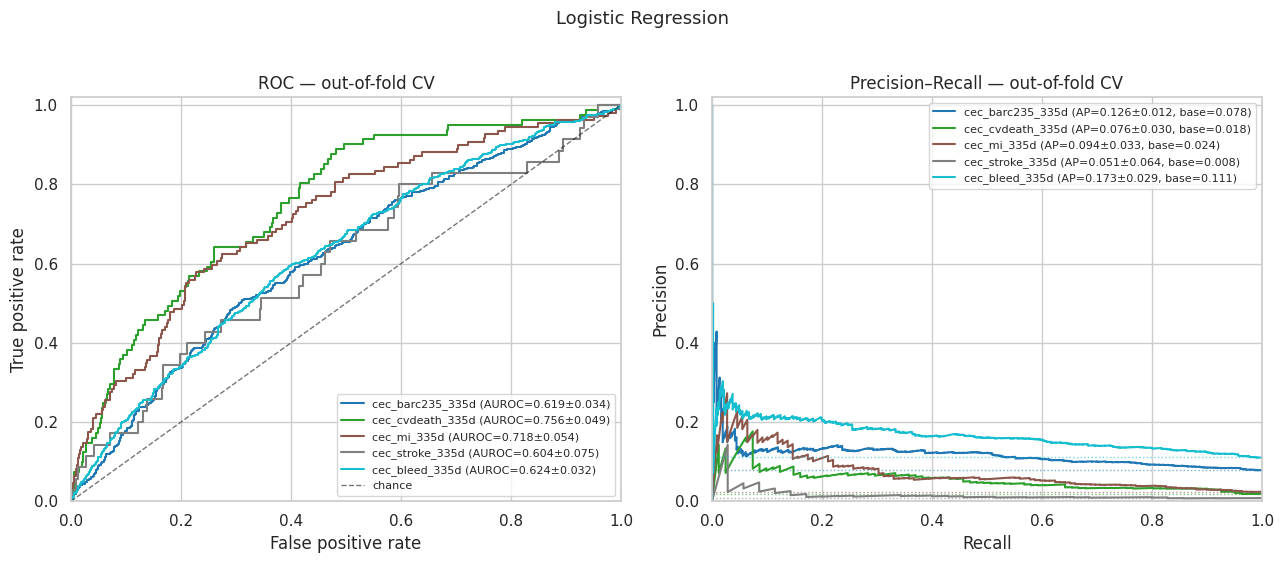

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.08,0.62,0.03,0.13,0.01,1.61
cec_cvdeath_335d,0.02,0.76,0.05,0.08,0.03,4.30
cec_mi_335d,0.02,0.72,0.05,0.09,0.03,3.96
cec_stroke_335d,0.01,0.60,0.08,0.05,0.06,6.61
cec_bleed_335d,0.11,0.62,0.03,0.17,0.03,1.57


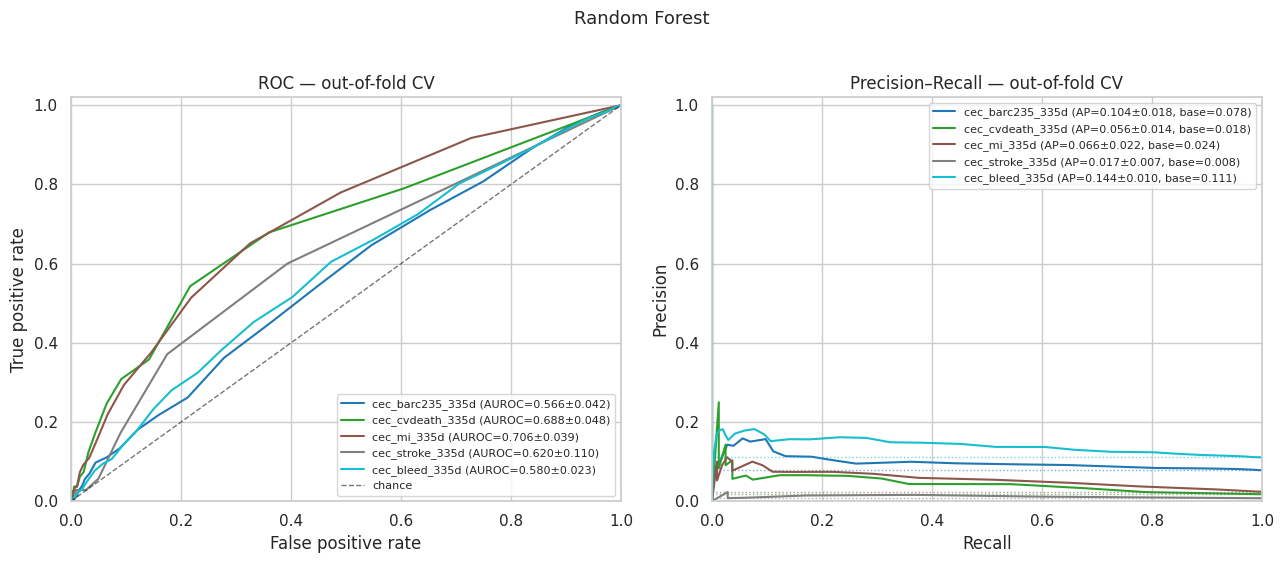

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.08,0.57,0.04,0.10,0.02,1.33
cec_cvdeath_335d,0.02,0.69,0.05,0.06,0.01,3.17
cec_mi_335d,0.02,0.71,0.04,0.07,0.02,2.77
cec_stroke_335d,0.01,0.62,0.11,0.02,0.01,2.16
cec_bleed_335d,0.11,0.58,0.02,0.14,0.01,1.30


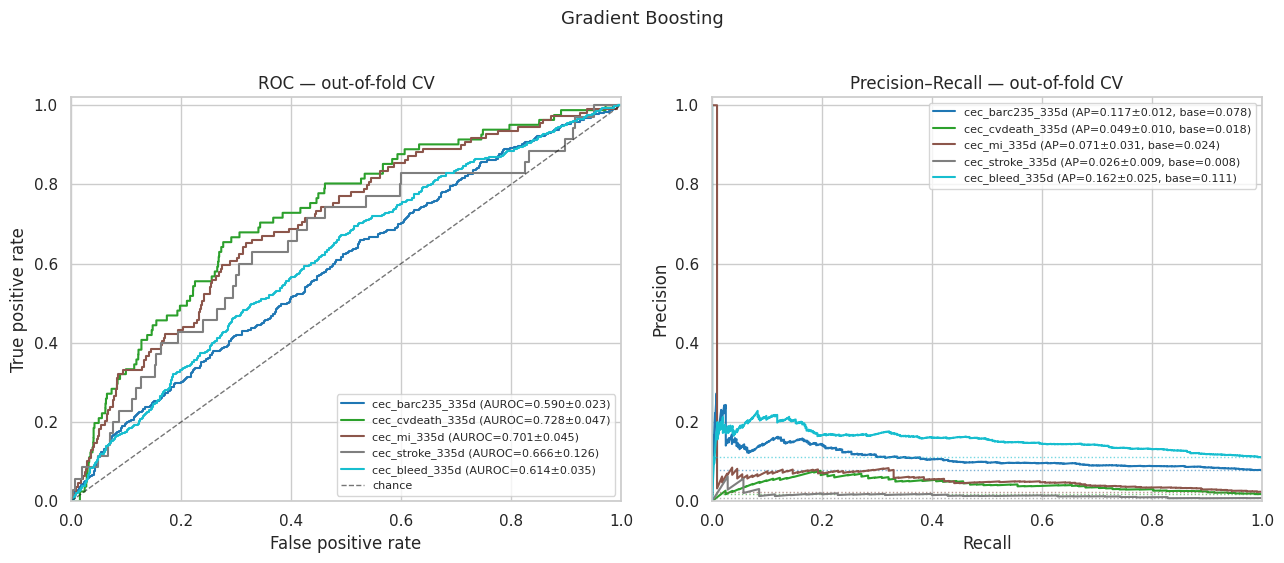

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.08,0.59,0.02,0.12,0.01,1.50
cec_cvdeath_335d,0.02,0.73,0.05,0.05,0.01,2.77
cec_mi_335d,0.02,0.70,0.04,0.07,0.03,2.97
cec_stroke_335d,0.01,0.67,0.13,0.03,0.01,3.35
cec_bleed_335d,0.11,0.61,0.04,0.16,0.02,1.47


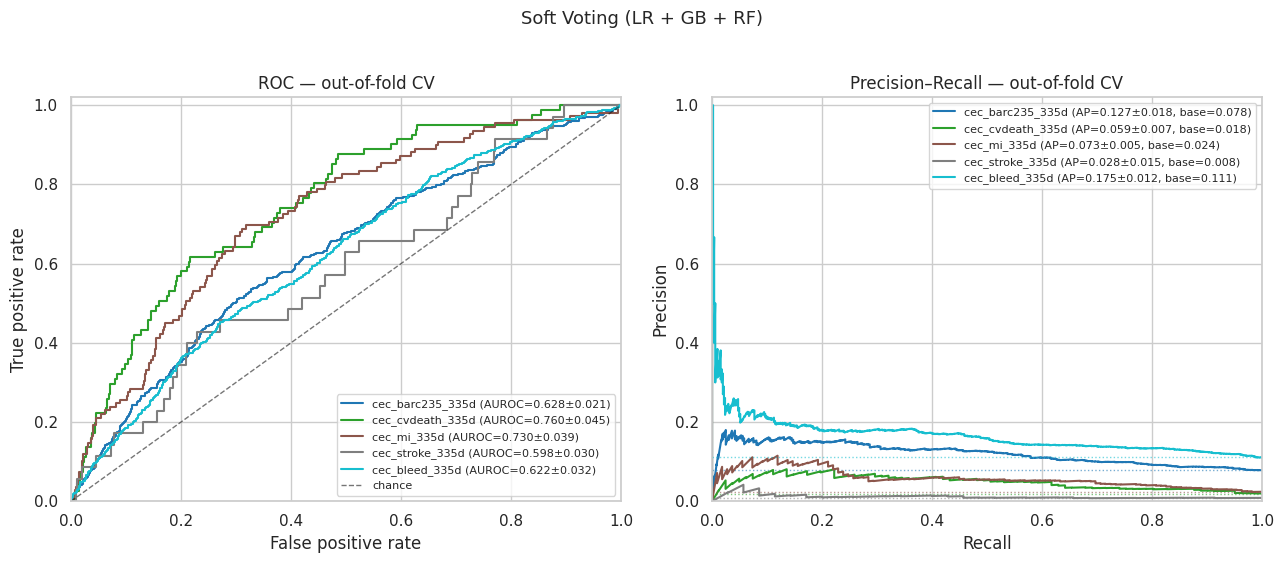

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.08,0.63,0.02,0.13,0.02,1.62
cec_cvdeath_335d,0.02,0.76,0.04,0.06,0.01,3.33
cec_mi_335d,0.02,0.73,0.04,0.07,0.01,3.07
cec_stroke_335d,0.01,0.60,0.03,0.03,0.01,3.70
cec_bleed_335d,0.11,0.62,0.03,0.17,0.01,1.58


In [11]:
# Threshold-free model assessment via cross-validation over the FULL dataset.
# Rather than fixing one decision threshold on a single train/test split, every
# row is scored once with an out-of-fold probability and the ROC / PR curves
# (AUROC / AUPRC, mean +/- std across folds) judge discrimination without
# choosing an operating point. Preprocessing is refit per fold -> no leakage.
X_cv = X.select_dtypes(include=[np.number])  # full feature matrix, numeric only

for _name, _pipe in [('Logistic Regression', lr_pipe),
                     ('Random Forest', rf_pipe),
                     ('Gradient Boosting', gb_pipe)]:
    display(cv_roc_pr_curves(_pipe, X_cv, y_df, cv=5, model_name=_name))

display(softvote_cv_roc_pr_curves(
    soft_vote.estimators, X_cv, y_df, cv=5, model_name='Soft Voting (LR + GB + RF)'))

## Bayesian Hyperparameter Tuning

Random and grid search waste budget exploring the whole parameter space uniformly. Optuna's Tree-structured Parzen Estimator (TPE) builds a probabilistic model of the objective surface after each trial and concentrates subsequent trials where the objective is likely to be high.

**Objective**: mean **average precision** (PR-AUC) across the targets on the training set (3-fold CV). Average precision is threshold-independent and focuses on the rare positive class, so the search optimises the model's ability to *rank* positives rather than a macro score dominated by the easy negative class.
**Trials**: 50 / 30 / 20 for Logistic Regression / Random Forest / Gradient Boosting.
After the search, the best hyperparameters are used to fit the final model and evaluate it on the held-out test set, using the **same** protocol as the baseline models above (event-rate threshold for every model, with threshold-independent PR-AUC / ROC-AUC reported alongside).

In [12]:
import optuna
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _multioutput_average_precision(estimator, X, y):
    # Callable scorer (estimator, X, y) -> mean average precision over the
    # targets, computed from predicted probabilities (threshold-independent).
    y = np.asarray(y, dtype=int)
    probas = estimator.predict_proba(X)  # list of (n, 2) arrays, one per target
    return float(np.mean([
        average_precision_score(y[:, j], probas[j][:, 1])
        for j in range(y.shape[1])
    ]))


def mean_cv_ap(pipeline, X, y, cv=3):
    scores = cross_val_score(pipeline, X, y, cv=cv,
                             scoring=_multioutput_average_precision, error_score=np.nan)
    return float(np.nanmean(scores))

### Logistic Regression

Search space: regularisation strength `C` (log-uniform in [0.001, 100]) and `solver` (lbfgs / liblinear / saga, all with L2 penalty).

In [13]:
def _lr_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            LogisticRegression(C=C, solver=solver, max_iter=2000,
                               random_state=42, class_weight='balanced'),
            n_jobs=-1,
        )),
    ])
    return mean_cv_ap(pipe, X_train, y_train)


study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(_lr_objective, n_trials=50, show_progress_bar=True)

# Baseline (default C=1, lbfgs) for delta comparison
_baseline_lr_ap = mean_cv_ap(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_lr.best_params)
print(f'Tuned  CV mean average precision: {study_lr.best_value:.4f}')
print(f'Base   CV mean average precision: {_baseline_lr_ap:.4f}  '
      f'(Δ = {study_lr.best_value - _baseline_lr_ap:+.4f})')

Best trial: 14. Best value: 0.110183: 100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


Best params: {'C': 0.15091593999575736, 'solver': 'lbfgs'}
Tuned  CV mean average precision: 0.1102
Base   CV mean average precision: 0.0967  (Δ = +0.0135)


Test set performance — Tuned Logistic Regression
target         rate  PR-AUC  lift  ROC-AUC   P(1)   R(1)  F1(1)
---------------------------------------------------------------
cec_barc235_335d  0.081   0.120  1.48    0.621   0.11   0.11   0.11
cec_cvdeath_335d  0.016   0.047  2.89    0.778   0.00   0.00   0.00
cec_mi_335d   0.024   0.100  4.16    0.700   0.14   0.09   0.11
cec_stroke_335d  0.008   0.165 21.54    0.597   0.14   0.14   0.14
cec_bleed_335d  0.119   0.167  1.40    0.609   0.21   0.20   0.21


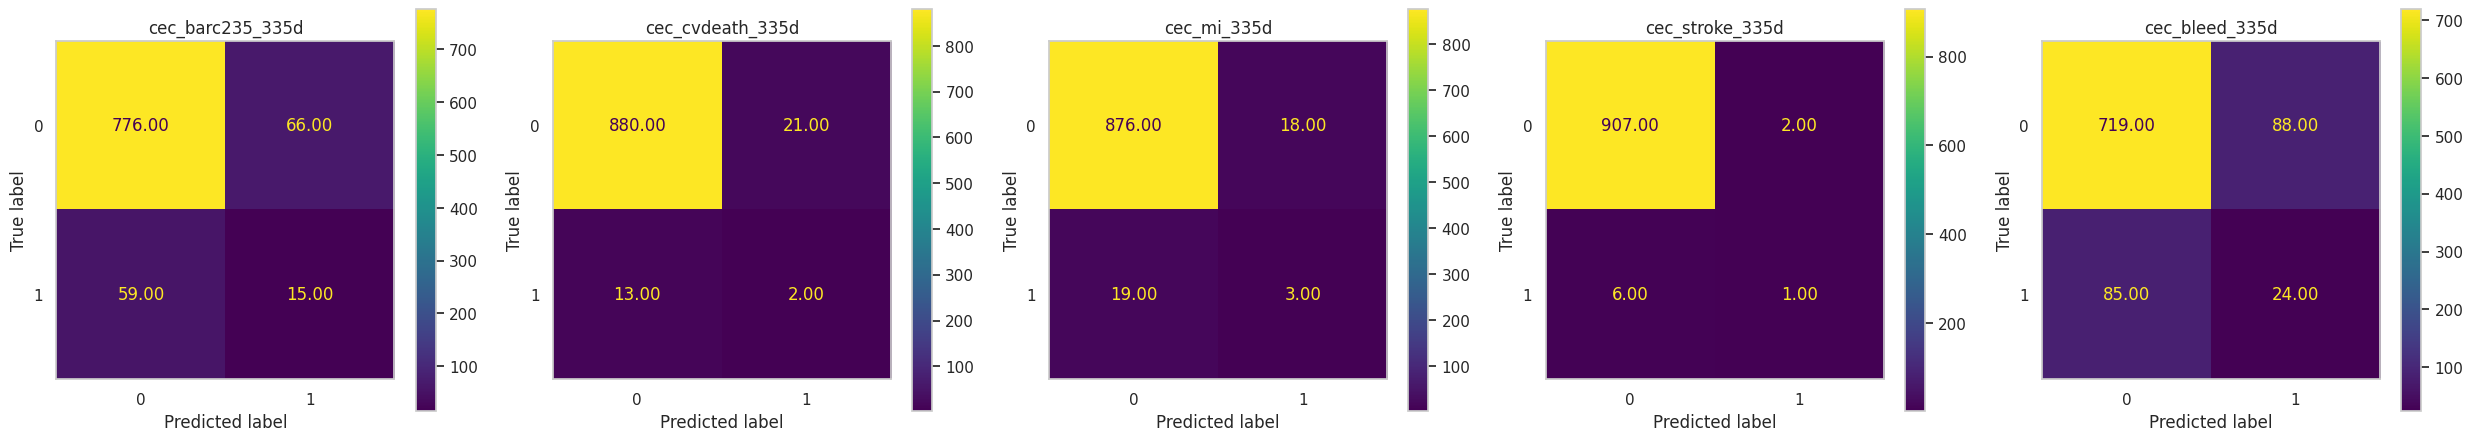

In [14]:
_p = study_lr.best_params
best_lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(C=_p['C'], solver=_p['solver'],
                           max_iter=2000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
])
best_lr_pipe.fit(X_train, y_train)

# Same event-rate thresholding as every other model, for a comparable operating point.
_thresholds = event_rate_thresholds(best_lr_pipe, X_train, y_train)

print('Test set performance — Tuned Logistic Regression')
_proba = predict_proba_matrix(best_lr_pipe, X_test)
_y_pred = predict_with_threshold(best_lr_pipe, X_test, _thresholds)

report_test_performance(y_test, _proba, _thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

### Random Forest

Search space: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`. For the test evaluation the per-target decision threshold is derived from the (1 − event_rate) quantile of the model's predicted training-set probabilities, making it adaptive to the actual probability range produced by the tuned hyperparameters.

In [15]:
def _rf_objective(trial):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42, n_jobs=3, class_weight='balanced'
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_ap(pipe, X_train, y_train)


study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(_rf_objective, n_trials=30, show_progress_bar=True)

_baseline_rf_ap = mean_cv_ap(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(random_state=42, n_jobs=3, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_rf.best_params)
print(f'Tuned  CV mean average precision: {study_rf.best_value:.4f}')
print(f'Base   CV mean average precision: {_baseline_rf_ap:.4f}  '
      f'(Δ = {study_rf.best_value - _baseline_rf_ap:+.4f})')

Best trial: 22. Best value: 0.100308: 100%|██████████| 30/30 [02:01<00:00,  4.06s/it] 


Best params: {'n_estimators': 350, 'max_depth': None, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'log2'}
Tuned  CV mean average precision: 0.1003
Base   CV mean average precision: 0.0748  (Δ = +0.0255)


Test set performance — Tuned Random Forest
target         rate  PR-AUC  lift  ROC-AUC   P(1)   R(1)  F1(1)
---------------------------------------------------------------
cec_barc235_335d  0.081   0.122  1.51    0.612   0.14   0.19   0.16
cec_cvdeath_335d  0.016   0.051  3.12    0.713   0.10   0.13   0.11
cec_mi_335d   0.024   0.084  3.49    0.731   0.05   0.05   0.05
cec_stroke_335d  0.008   0.017  2.23    0.631   0.00   0.00   0.00
cec_bleed_335d  0.119   0.175  1.47    0.627   0.24   0.28   0.26


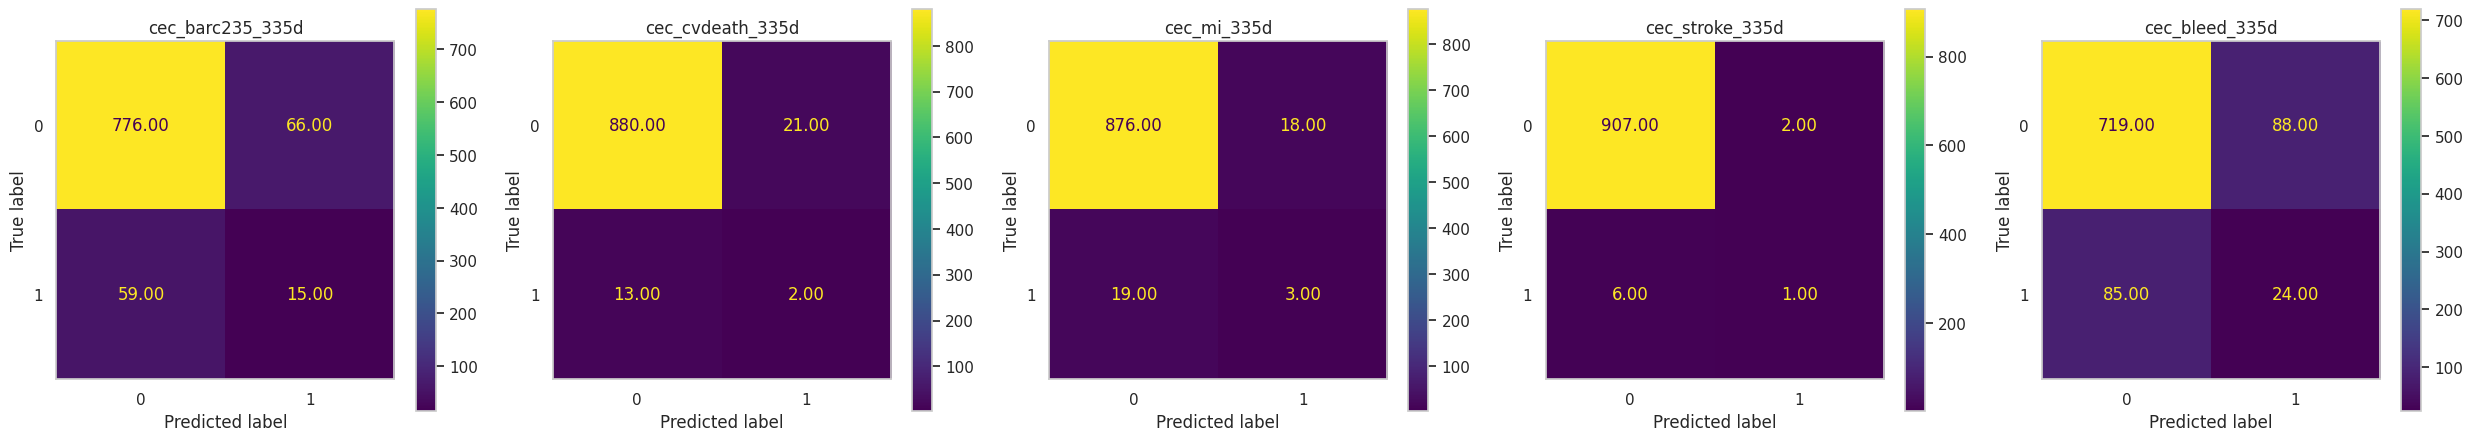

In [16]:
_p = study_rf.best_params
best_rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            min_samples_split=_p['min_samples_split'],
            min_samples_leaf=_p['min_samples_leaf'],
            max_features=_p['max_features'],
            class_weight='balanced', random_state=42, n_jobs=-1,
        ),
        n_jobs=-1,
    )),
])
best_rf_pipe.fit(X_train, y_train)

# Per-target thresholds from the (1 - event_rate) quantile of out-of-fold
# probabilities.  Using out-of-fold rather than in-sample probabilities is
# essential here: the tuned trees overfit the training set, so an in-sample
# quantile threshold lands far above the test probabilities and predicts the
# negative class for every row.
_thresholds = event_rate_thresholds(best_rf_pipe, X_train, y_train)

print('Test set performance — Tuned Random Forest')
_proba = predict_proba_matrix(best_rf_pipe, X_test)
_y_pred = predict_with_threshold(best_rf_pipe, X_test, _thresholds)

report_test_performance(y_test, _proba, _thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

### Gradient Boosting

Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_split`, `max_features`. Same quantile-based evaluation as RF.

In [17]:
def _gb_objective(trial):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 2, 6),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_ap(pipe, X_train, y_train)


study_gb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(_gb_objective, n_trials=20, show_progress_bar=True)

_baseline_gb_ap = mean_cv_ap(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_gb.best_params)
print(f'Tuned  CV mean average precision: {study_gb.best_value:.4f}')
print(f'Base   CV mean average precision: {_baseline_gb_ap:.4f}  '
      f'(Δ = {study_gb.best_value - _baseline_gb_ap:+.4f})')

Best trial: 11. Best value: 0.0981048: 100%|██████████| 20/20 [00:38<00:00,  1.93s/it]


Best params: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.012423369849791508, 'subsample': 0.7773686484953347, 'min_samples_split': 13, 'max_features': 'log2'}
Tuned  CV mean average precision: 0.0981
Base   CV mean average precision: 0.0921  (Δ = +0.0060)


Test set performance — Tuned Gradient Boosting
target         rate  PR-AUC  lift  ROC-AUC   P(1)   R(1)  F1(1)
---------------------------------------------------------------
cec_barc235_335d  0.081   0.134  1.66    0.619   0.14   0.15   0.14
cec_cvdeath_335d  0.016   0.046  2.84    0.776   0.07   0.07   0.07
cec_mi_335d   0.024   0.111  4.60    0.748   0.18   0.14   0.15
cec_stroke_335d  0.008   0.011  1.48    0.556   0.00   0.00   0.00
cec_bleed_335d  0.119   0.176  1.48    0.614   0.20   0.18   0.19


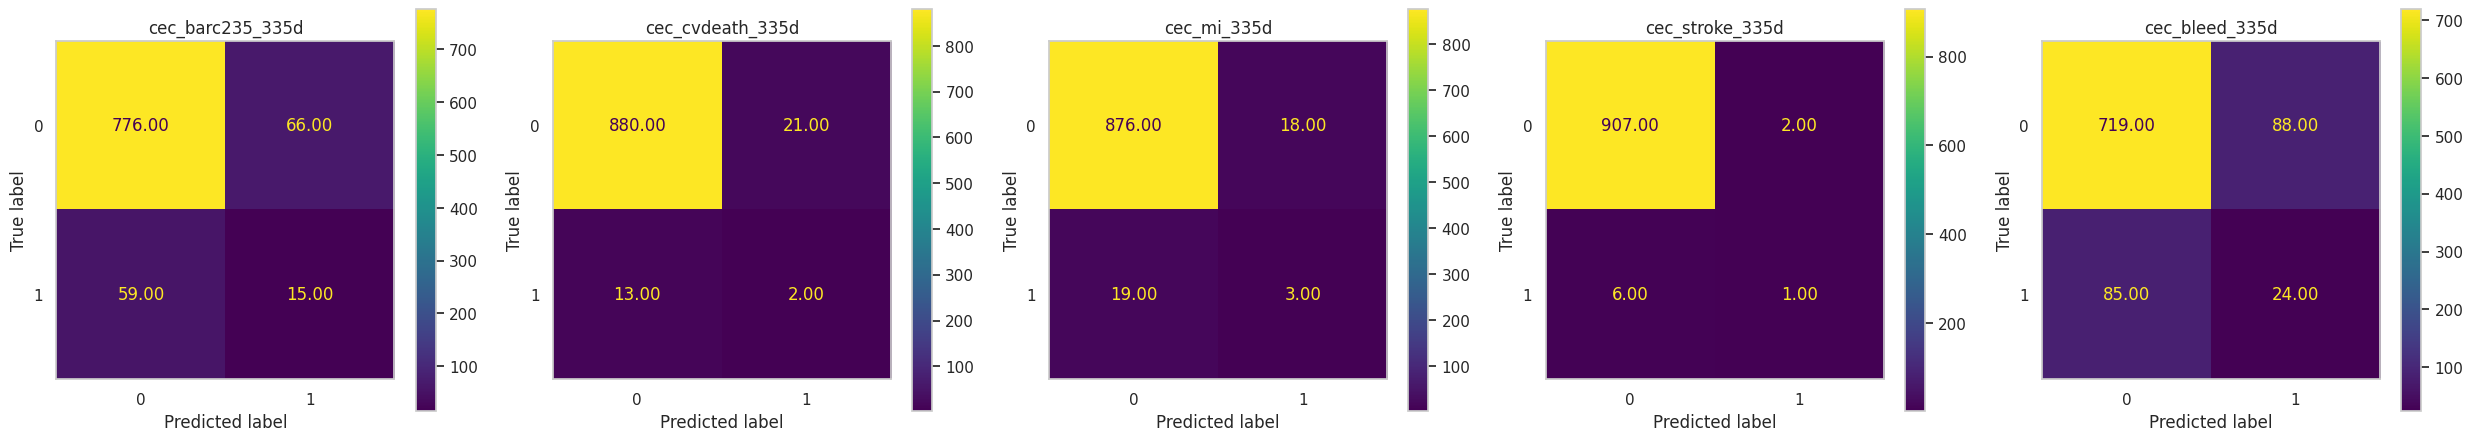

In [18]:
_p = study_gb.best_params
best_gb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            learning_rate=_p['learning_rate'], subsample=_p['subsample'],
            min_samples_split=_p['min_samples_split'], max_features=_p['max_features'],
            random_state=42,
        ),
        n_jobs=-1,
    )),
])
best_gb_pipe.fit(X_train, y_train)

# Same out-of-fold quantile thresholds as for the tuned RF above, for consistency.
_thresholds = event_rate_thresholds(best_gb_pipe, X_train, y_train)

print('Test set performance — Tuned Gradient Boosting')
_proba = predict_proba_matrix(best_gb_pipe, X_test)
_y_pred = predict_with_threshold(best_gb_pipe, X_test, _thresholds)

report_test_performance(y_test, _proba, _thresholds)
plot_confusion_matrices(y_test, y_pred, normalize=False)

### Summary

Comparison of cross-validated mean average precision (PR-AUC, 3-fold, training set) before and after Bayesian tuning, and the convergence of the best-so-far objective across trials.

              Model  Baseline CV PR-AUC  Tuned CV PR-AUC  Δ PR-AUC
Logistic Regression                0.10             0.11      0.01
      Random Forest                0.07             0.10      0.03
  Gradient Boosting                0.09             0.10      0.01


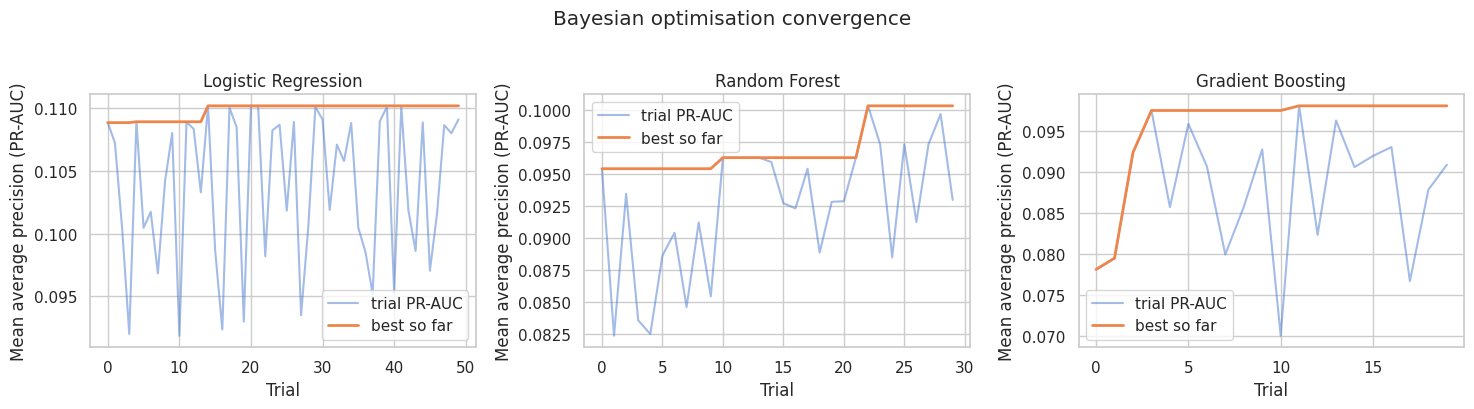

In [19]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline CV PR-AUC': [_baseline_lr_ap, _baseline_rf_ap, _baseline_gb_ap],
    'Tuned CV PR-AUC':    [study_lr.best_value, study_rf.best_value, study_gb.best_value],
})
comparison['Δ PR-AUC'] = comparison['Tuned CV PR-AUC'] - comparison['Baseline CV PR-AUC']
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, study) in zip(
    axes,
    [('Logistic Regression', study_lr),
     ('Random Forest',       study_rf),
     ('Gradient Boosting',   study_gb)],
):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.5, label='trial PR-AUC')
    ax.plot(best_so_far, linewidth=2, label='best so far')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Mean average precision (PR-AUC)')
    ax.legend()
plt.suptitle('Bayesian optimisation convergence', y=1.02)
plt.tight_layout()
plt.show()